In [190]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from lacbox.io import load_stats, load_oper

In [191]:
# analysis settings
HAWC2S_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\hawc_files\our_design\data\group7_3B_design_flex.opt'  # path to .pwr or .opt file
STATS_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\A4 Design Loads and AEP\Assignment/group7_turbB_stats_ts.csv'  # path to mean steady stats
SUBFOLDER = 'tcb'  # which subfolder to plot: tca or tcb

# turbine constants
GENEFF = 0.94  # generator/gearbox efficienty [%]
FG_TIMES_DY = 6250  # yaw-bearing pitch moment due to gravity [kNm]
if 'notilt' in SUBFOLDER:
    DZ_YB = 2.75  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
else:
    DZ_YB = 2.75 + 7.1*np.sin(5*np.pi/180)  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
CHAN_DESCS = {'BldPit': 'pitch1 angle',  # dictionary used to identify which descriptions
              'RotSpd': 'rotor speed',  # in the HAWC2 statistics file correspond to which
              'Thrust': 'aero rotor thrust',  # channels we want
              'GenTrq': 'generator torque',
              'ElPow': 'pelec',
              'TbFA': 'momentmx mbdy:tower nodenr:   1',
              'TbSS': 'momentmy mbdy:tower nodenr:   1',
              'YbTilt': 'momentmx mbdy:tower nodenr:  11',
              'YbRoll': 'momentmy mbdy:tower nodenr:  11',
              'ShftTrs': 'momentmz mbdy:shaft nodenr:   4',
              'OoPBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: hub1',
              'IPBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: hub1',
              'FlpBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: blade1',
              'EdgBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: blade1',
              'OoPHub': 'momentmx mbdy:hub1 nodenr:   1 coo: hub1',
              'IPHub': 'momentmy mbdy:hub1 nodenr:   1 coo: hub1',
              }

# what channels we want to plot
chan_ids = ['BldPit', 'RotSpd', 'Thrust', 'GenTrq', 'ElPow', 'TbFA', 'TbSS',
            'YbTilt', 'YbRoll', 'ShftTrs', 'OoPBRM', 'IPBRM', 'FlpBRM', 'EdgBRM'  ]

turb_ids = ['path', 'filename', 'subfolder', 'ichan', 'names', 'units', 'desc',
            'mean', 'max', 'min', 'std', '1%', '50%', '99%', 'del3', 'del4', 'del5',
            'del8', 'del10', 'del12', 'wsp']

# load the HAWC2 data from the stats file. Isolate the simulations with no tilt.
df, wsps = load_stats(STATS_PATH, statstype='turb')


In [192]:
df.columns

Index(['path', 'filename', 'subfolder', 'ichan', 'names', 'units', 'desc',
       'mean', 'max', 'min', 'std', '1%', '50%', '99%', 'del3', 'del4', 'del5',
       'del8', 'del10', 'del12', 'wsp'],
      dtype='object')

TbFA
TbSS
YbTilt
YbRoll
ShftTrs
OoPBRM
IPBRM


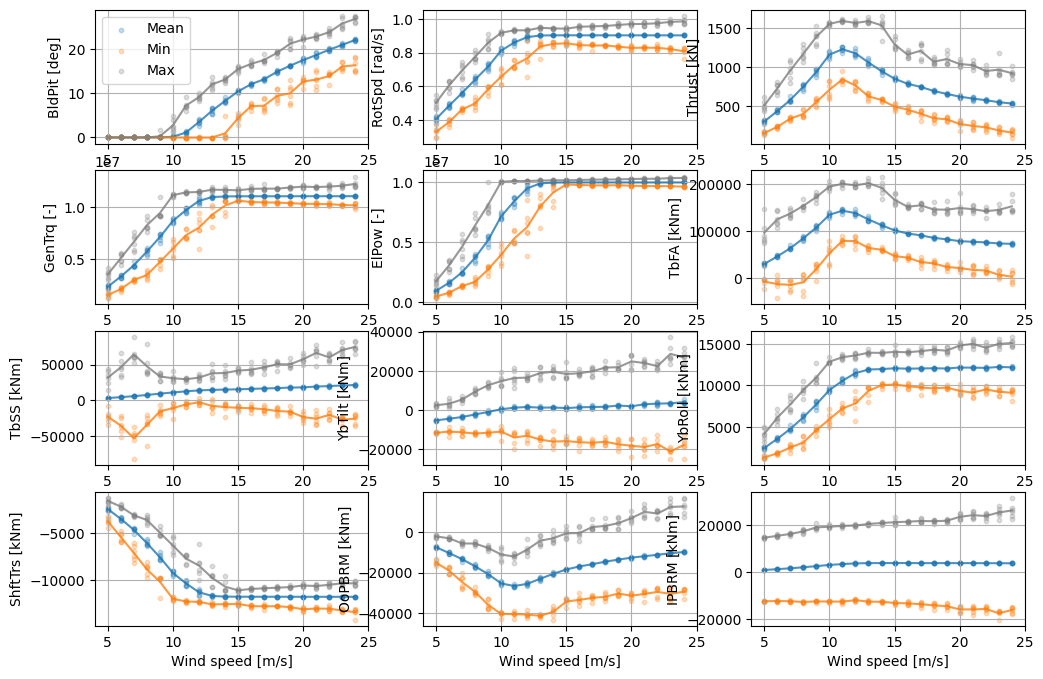

In [ ]:
# analysis settings
HAWC2S_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\hawc_files\our_design\data\group7_3B_design_flex.opt'  # path to .pwr or .opt file
STATS_PATH = r'C:\Users\hrara\Documents\46320_LAC\LAC_Assignments_Git\A4 Design Loads and AEP\Assignment/group7_turbB_stats_ts.csv'  # path to mean steady stats
SUBFOLDER = 'tcb'  # which subfolder to plot: tca or tcb

# turbine constants
GENEFF = 0.94  # generator/gearbox efficienty [%]
FG_TIMES_DY = 6250  # yaw-bearing pitch moment due to gravity [kNm]

m_tower = "del3" # "del4"
if 'notilt' in SUBFOLDER:
    DZ_YB = 2.75  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
else:
    DZ_YB = 2.75 + 7.1*np.sin(5*np.pi/180)  # distance from hub center to yaw bearing [m]
    DZ_TB = 115.63 + DZ_YB  # distance from hub center to tower base [m]
CHAN_DESCS = {'BldPit': 'pitch1 angle',  # dictionary used to identify which descriptions
              'RotSpd': 'rotor speed',  # in the HAWC2 statistics file correspond to which
              'Thrust': 'aero rotor thrust',  # channels we want
              'GenTrq': 'generator torque',
              'ElPow': 'pelec',
              'TbFA': 'momentmx mbdy:tower nodenr:   1',
              'TbSS': 'momentmy mbdy:tower nodenr:   1',
              'YbTilt': 'momentmx mbdy:tower nodenr:  11',
              'YbRoll': 'momentmy mbdy:tower nodenr:  11',
              'ShftTrs': 'momentmz mbdy:shaft nodenr:   4',
              'OoPBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: hub1',
              'IPBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: hub1',
             'EdgBRM': 'momentmx mbdy:blade1 nodenr:   1 coo: blade1  blade1 root flped',
              'FlpBRM': 'momentmy mbdy:blade1 nodenr:   1 coo: blade1  blade1 root flped',
              'OoPHub': 'momentmx mbdy:hub1 nodenr:   1 coo: hub1',
              'IPHub': 'momentmy mbdy:hub1 nodenr:   1 coo: hub1',
              }




# what channels we want to plot
chan_ids = ['BldPit', 'RotSpd', 'Thrust', 'GenTrq', 'ElPow', 'TbFA', 'TbSS',
            'YbTilt', 'YbRoll', 'ShftTrs', 'OoPBRM', 'IPBRM', "EdgBRM", "FlpBRM"]

turb_ids = ['path', 'filename', 'subfolder', 'ichan', 'names', 'units', 'desc',
            'mean', 'max', 'min', 'std', '1%', '50%', '99%', 'del3', 'del4', 'del5',
            'del8', 'del10', 'del12', 'wsp']

# load the HAWC2 data from the stats file. Isolate the simulations with no tilt.
df, wsps = load_stats(STATS_PATH, statstype='turb')

# 10 MW file 
# dtu10, wsps_dtu = load_stats('dtu_10mw_turb_stats.hdf5', subfolder="tca",statstype='turb', )
dtu10, wsps_dtu = load_stats('dtu_10mw_turb_stats.hdf5', subfolder="tca",statstype='turb', )

# load/calc. the stuff we need from the HAWC2S opt/pwr file for the operational data comparisons
opt_dict = load_oper(HAWC2S_PATH)
h2s_u, h2s_pitch, h2s_rotspd, = opt_dict['ws_ms'], opt_dict['pitch_deg'], opt_dict['rotor_speed_rpm']
h2s_paero, h2s_thrust = opt_dict['power_kw'], opt_dict['thrust_kn']
h2s_aerotrq = h2s_paero / (h2s_rotspd * np.pi / 30)

# get hawc2 thrust and aerodynamic torque for theoretical calculations
h2_thrust = df.filter_channel('Thrust', CHAN_DESCS)['mean']
h2_aero_trq = df.filter_channel('GenTrq', CHAN_DESCS)['mean'] / GENEFF * 1e-3  # aerodynamic torque [kNm]

# initialize the figure and axes
fig, axs = plt.subplots(4, 3, figsize=(12, 8), clear=True)

# Set the opacity and marker size variables
dot_opacity = 0.25  # Opacity for individual points
line_opacity = 0.8  # Opacity for the mean lines
dot_size = 10       # Size for individual points
line_size = 40      # Size for mean points
max_color = 'tab:gray'
mean_color = 'tab:blue'
min_color = 'tab:orange'

interested = ["TbFA", "TbSS", "IPBRM", "OoPBRM", "ShftTrs", "YbTilt", :]
power_e = []
power_dtu = []
dfs = []
dtu = []
# Loop over each channel and plot the steady state with the theory line
for iplot, chan_id in enumerate(chan_ids):

    
    # Isolate the channel data
    chan_df = df.filter_channel(chan_id, CHAN_DESCS)
    chan_df_dtu = dtu10.filter_channel(chan_id, CHAN_DESCS)

    # Extract HAWC2 wind and the stats ('mean', 'min', 'max') for the channel
    h2_wind = np.array(chan_df['wsp'])
    h2_wind_dtu = np.array(chan_df_dtu['wsp'])

    HAWC2val_mean = np.array(chan_df['mean'])
    HAWC2val_min = np.array(chan_df['min'])
    HAWC2val_max = np.array(chan_df['max'])

    if chan_id=="ElPow":
        power_e.append(chan_df)
        power_dtu.append(chan_df_dtu)

    if chan_id in interested:
        print(chan_id)
        dfs.append(chan_df)
        dtu.append(chan_df_dtu)

    # Sort HAWC2 values by increasing wind speed
    i_h2 = np.argsort(h2_wind)
    h2_wind_sorted = h2_wind[i_h2]
    HAWC2val_mean_sorted = HAWC2val_mean[i_h2]
    HAWC2val_min_sorted = HAWC2val_min[i_h2]
    HAWC2val_max_sorted = HAWC2val_max[i_h2]

    # Calculate the mean for each unique wind speed for 'mean', 'min', and 'max'
    unique_wind_speeds = np.unique(h2_wind_sorted)
    mean_HAWC2val_per_wind = [np.mean(HAWC2val_mean_sorted[h2_wind_sorted == wsp]) for wsp in unique_wind_speeds]
    min_HAWC2val_per_wind = [np.mean(HAWC2val_min_sorted[h2_wind_sorted == wsp]) for wsp in unique_wind_speeds]
    max_HAWC2val_per_wind = [np.mean(HAWC2val_max_sorted[h2_wind_sorted == wsp]) for wsp in unique_wind_speeds]

    # Plot the results
    ax = axs.flatten()[iplot]
    # Individual 'mean' values with lower opacity and smaller markers
    ax.scatter(h2_wind_sorted, HAWC2val_mean_sorted, color=mean_color, alpha=dot_opacity, s=dot_size, label='Mean')
    # Mean of 'mean' with higher opacity and larger markers
    ax.plot(unique_wind_speeds, mean_HAWC2val_per_wind, color=mean_color, alpha=line_opacity, markersize=line_size)#, label='Mean of means')

    # Individual 'min' values
    ax.scatter(h2_wind_sorted, HAWC2val_min_sorted, color=min_color, alpha=dot_opacity, s=dot_size, label='Min')
    # Mean of 'min'
    ax.plot(unique_wind_speeds, min_HAWC2val_per_wind, color=min_color, alpha=line_opacity, markersize=line_size)#, label='Mean of min')

    # Individual 'max' values
    ax.scatter(h2_wind_sorted, HAWC2val_max_sorted, color=max_color, alpha=dot_opacity, s=dot_size, label='Max')
    # Mean of 'max'
    ax.plot(unique_wind_speeds, max_HAWC2val_per_wind, color=max_color, alpha=line_opacity, markersize=line_size)#, label='Mean of max')

    # Formatting the plot
    ax.grid('on')
    ax.set(xlabel='Wind speed [m/s]' if iplot > 8 else None,
           ylabel=f'{chan_id} [{chan_df.units.iloc[0]}]', xlim=[4, 25])

# Add legends and format the figure
axs[0, 0].legend()
#axs[1, 2].legend()
# fig.suptitle(f'Case: Group 7 design - {SUBFOLDER}')
# fig.tight_layout()

In [ ]:
np.unique(h2_wind)

mean_values = [dfs[0]["del3"][i:i + 6].mean() for i in range(0, len(dfs[0]["del3"]) - 5, 6)]


# Get the sorting indices for h2_wind_dtu in increasing order
sorted_indices = np.argsort(h2_wind_dtu)

# Sort both arrays using the same indices
h2_wind_dtu_sorted = h2_wind_dtu[sorted_indices]
dtu_del3_sorted = dtu[0]["del3"].to_numpy()[sorted_indices]  # Convert to numpy array for indexing

# Convert dtu_del3_sorted back to a pandas Series if needed
dtu_del3_sorted = pd.Series(dtu_del3_sorted)
m_tbfa_dtu = dtu_del3_sorted.rolling(window=6).mean().iloc[5::6].reset_index(drop=True)


def sort_and_rolling_mean(h2_wind_dtu, dtu_del3, window=6):

    # Get sorting indices for h2_wind_dtu in increasing order
    sorted_indices = np.argsort(h2_wind_dtu)

    # Sort both arrays using the same indices
    h2_wind_dtu_sorted = h2_wind_dtu[sorted_indices]
    dtu_del3_sorted = dtu_del3.to_numpy()[sorted_indices]  # Convert to numpy array for indexing

    # Convert sorted dtu_del3 back to pandas Series for rolling operation
    dtu_del3_sorted = pd.Series(dtu_del3_sorted)

    # Calculate rolling mean and select every `window` step
    m_tbfa_dtu = dtu_del3_sorted.rolling(window=window).mean().iloc[window-1::window].reset_index(drop=True)
    
    return h2_wind_dtu_sorted, m_tbfa_dtu

h2_wind_dtu_sorted, m_tbfa_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[0]["del3"])
h2_wind_dtu_sorted, m_tbss_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[1]["del3"])
h2_wind_dtu_sorted, m_oop_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[3]["del12"])
h2_wind_dtu_sorted, m_ip_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[4]["del12"])
h2_wind_dtu_sorted, m_shat_torsion_dtu = sort_and_rolling_mean(h2_wind_dtu, dtu[2]["del3"])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, axs = plt.subplots(3, 3, figsize=(17, 12))

# Plotting and setting y-axis labels
m_tbfa = [dfs[0]["del3"][i:i + 6].mean() for i in range(0, len(dfs[0]["del3"]) - 5, 6)]
axs[0, 0].scatter(h2_wind, dfs[0]["del3"], label="Our Design", c='tab:blue', alpha=0.75)
axs[0, 0].scatter(h2_wind_dtu, dtu[0]["del3"], label="DTU 10 MW", c='tab:orange', alpha=0.75)
axs[0, 0].plot(np.unique(h2_wind), m_tbfa, label="Our Design", c='k')
axs[0, 0].plot(np.unique(h2_wind_dtu), m_tbfa_dtu, c='r')
axs[0, 0].set_ylabel("TbFA [kN.m]")
axs[0, 0].set_xticks(range(5, 26, 2))
axs[0, 0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[0, 0].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Repeat similar changes for other subplots
m_tbss = [dfs[1]["del3"][i:i + 6].mean() for i in range(0, len(dfs[1]["del3"]) - 5, 6)]
axs[0, 1].scatter(h2_wind, dfs[1]["del3"], c='tab:blue', alpha=0.75)
axs[0, 1].scatter(h2_wind_dtu, dtu[1]["del3"], label="DTU 10 MW", c='tab:orange', alpha=0.75)
# axs[0, 1].yaxis.tick_right()
# axs[0, 1].yaxis.set_label_position("right")
axs[0, 1].plot(np.unique(h2_wind), m_tbss, label="Our Design", c='k')
axs[0, 1].plot(np.unique(h2_wind_dtu), m_tbss_dtu, c='r')
axs[0, 1].set_ylabel("TbSS [kN.m]")
axs[0, 1].set_xticks(range(5, 26, 2))
axs[0, 1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[0, 1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

m_oop = [dfs[3]["del12"][i:i + 6].mean() for i in range(0, len(dfs[3]["del12"]) - 5, 6)]
axs[0, 2].scatter(h2_wind, dfs[3]["del12"], c='tab:blue', alpha=0.75)
axs[0, 2].scatter(h2_wind_dtu, dtu[3]["del12"], label="DTU 10 MW", c='tab:orange', alpha=0.75)
axs[0, 2].set_ylabel("OoPBRM [kN.m]")
axs[0, 2].set_xlabel("Wind Speed [m/s]")
axs[0, 2].set_xticks(range(5, 26, 2))
axs[0, 2].plot(np.unique(h2_wind), m_oop, label="Our Design", c='k')
axs[0, 2].plot(np.unique(h2_wind_dtu), m_oop_dtu, c='r')
axs[0, 2].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[0, 2].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

m_ip = [dfs[4]["del12"][i:i + 6].mean() for i in range(0, len(dfs[4]["del12"]) - 5, 6)]
axs[1, 0].scatter(h2_wind, dfs[4]["del12"], c='tab:blue', alpha=0.75, label="DEL Our Design")
axs[1, 0].scatter(h2_wind_dtu, dtu[4]["del12"], label="DEL DTU 10 MW", c='tab:orange', alpha=0.75)
axs[1, 0].plot(np.unique(h2_wind), m_ip, label="Mean DEL Our Design", c='k')
axs[1, 0].plot(np.unique(h2_wind_dtu), m_ip_dtu, c='r', label="Mean DEL DTU 10MW")
# axs[1, 0].yaxis.tick_right()
# axs[1, 0].yaxis.set_label_position("right")
axs[1, 0].set_ylabel("IPBRM [kN.m]")
axs[1, 0].set_xlabel("Wind Speed [m/s]")
axs[1, 0].set_xticks(range(5, 26, 2))
axs[1, 0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1, 0].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
axs[1, 0].legend()


m_st = [dfs[2]["del3"][i:i + 6].mean() for i in range(0, len(dfs[4]["del3"]) - 5, 6)]
axs[1,1].scatter(h2_wind_dtu, dtu[2]["del3"], label="DTU 10MW", c='tab:orange', alpha=0.75)
axs[1,1].scatter(h2_wind, dfs[2]["del3"], label="Our Design", c='tab:blue', alpha=0.75)
axs[1,1].plot(np.unique(h2_wind), m_st, label="Mean DEL Our Design", c='k')
axs[1,1].plot(np.unique(h2_wind_dtu), m_shat_torsion_dtu, label="Mean DEL DTU 10MW", c='r')
axs[1,1].set_ylabel("Shaft Torsion [kN.m]")
axs[1,1].set_xlabel("Wind Speed [m/s]")
axs[1,1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))




#flap
m_st = [dfs[2]["del3"][i:i + 6].mean() for i in range(0, len(dfs[4]["del3"]) - 5, 6)]
axs[1,1].scatter(h2_wind_dtu, dtu[2]["del3"], label="DTU 10MW", c='tab:orange', alpha=0.75)
axs[1,1].scatter(h2_wind, dfs[2]["del3"], label="Our Design", c='tab:blue', alpha=0.75)
axs[1,1].plot(np.unique(h2_wind), m_st, label="Mean DEL Our Design", c='k')
axs[1,1].plot(np.unique(h2_wind_dtu), m_shat_torsion_dtu, label="Mean DEL DTU 10MW", c='r')
axs[1,1].set_ylabel("Shaft Torsion [kN.m]")
axs[1,1].set_xlabel("Wind Speed [m/s]")
axs[1,1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))




# Apply grid to each subplot
for ax in axs.flat:
    ax.grid()


# Second figure for shaft torsion
fig, axs = plt.subplots(1, 1, figsize=(6, 3))


In [ ]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import weibull_min

# Given data
edges = np.array([4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5,
                  18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5])
probabilities = np.array([0.09822154, 0.10112075, 0.09843279, 0.09128194, 0.08103839, 0.06910383,
                          0.05673472, 0.04492539, 0.03435648, 0.02540085, 0.01817049, 0.01258493,
                          0.00844375, 0.00549053, 0.0034614, 0.00211633, 0.00125524, 0.00072242,
                          0.0004035, 0.00021877])
power = np.array([0.90281594, 1.51965107, 2.78623738, 3.98770741, 5.31902375, 7.33295203,
                  8.78195214, 9.65458228, 9.95934437, 9.99844496, 10.00005272, 10.00007685,
                  10.00009313, 10.00010151, 10.00010282, 10.00014001, 10.00018755, 10.00018745,
                  10.00019674, 10.00022433])

AEP_3B_DTU = np.sum(probabilities*power)*8760
AEP_3B_DTU/1e3 #GWh


In [ ]:
import numpy as np 
probabilities = np.array([0.06442809, 0.0709227,  0.07472189, 0.07591763, 0.0747455,  0.07155162,
 0.06675382, 0.06080169, 0.05413969, 0.04717648, 0.04026251, 0.03367663,
 0.02762128, 0.02222493, 0.01755019, 0.01360521, 0.01035688, 0.00774379,
 0.00568809, 0.0041053])



power = np.array([1.02044173,  1.83961791,  2.62376662,  3.88467137,  5.36878674,  7.42730361,
  8.68346048,  9.69612816,  9.8821354,   9.99911224,  9.99958796, 10.00012883,
 10.00012737, 10.00011983, 10.00016962, 10.00020958, 10.00021191, 10.00028012,
 10.00029822, 10.00033473])
AEP_1A_DTU = np.sum(probabilities*power)*8760
AEP_1A_DTU/1e3 #GWh

## Our Design

In [ ]:
U_bar_3 = 0.2*37.5
C3 = 1.13*U_bar_3
k3 = 2
V3 = np.arange(1,25)
prob_3b =  (k3 / C3) * (V3/ C3)**(k3 - 1) * np.exp(-(V3 / C3)**k3)
pelec_values = power_e[0]['mean']  # Accessing the column 'mean' which contains pelec [w] values

wsp = power_e[0]['wsp']
pelec_averages = [pelec_values[i:i+6].mean() for i in range(0, len(pelec_values), 6)]
wsp_averages = [wsp[i:i+6].mean() for i in range(0, len(wsp), 6)]
pelec_averages = np.array(pelec_averages)/1e6
AEP_3B = np.sum(prob_3b[4:]*pelec_averages)*8760
AEP_3B/1e3 # Gwh
pelec_values

In [ ]:
#DTU10 IB
import math
V_ave = 10
V3 = np.arange(5,25)
prob = (1 - np.exp(-np.pi * (V3/(2*V_ave))**2))

pelec_values = power_dtu[0]['mean']  # Accessing the column 'mean' which contains pelec [w] values


sorted_indices = np.argsort(wsp)

pelec_values = pelec_values.values[sorted_indices]

wsp = power_dtu[0]['wsp']
pelec_averages = [pelec_values[i:i+6].mean() for i in range(0, len(pelec_values), 6)]
wsp_averages = [wsp[i:i+6].mean() for i in range(0, len(wsp), 6)]
pelec_averages = np.array(pelec_averages)/1e6
AEP_3B = np.sum(prob*pelec_averages)*8760
AEP_3B/1e3 # Gwh

In [ ]:
probabilities = np.array([0.06442809, 0.0709227,  0.07472189, 0.07591763, 0.0747455,  0.07155162,
 0.06675382, 0.06080169, 0.05413969, 0.04717648, 0.04026251, 0.03367663,
 0.02762128, 0.02222493, 0.01755019, 0.01360521, 0.01035688, 0.00774379,
 0.00568809, 0.0041053])

In [ ]:
probabilities

In [ ]:
prob

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Data
# bin_probabilities = prob_3b[4:] * 100

# # Assuming each bin represents a wind speed value (adjust as needed)
# wind_speed_bins = np.linspace(5, 25, len(bin_probabilities))  # Wind speed values from 5 to 25 m/s

# # Calculate weighted power (assuming 8760 hours per year)
# weighted_power = (pelec_averages * bin_probabilities / 100 * 8760) / 1e3  # in GWh

# # Create figure with increased size
# fig, ax1 = plt.subplots(figsize=(12, 10))  # Increased figure size

# # Plot bin probabilities as a red curve on the left y-axis with higher zorder
# ax1.plot(wind_speed_bins, pelec_averages, 'o-', color='orange', label='Power curve')
# ax1.plot(wind_speed_bins, bin_probabilities, 'o-', color='red', label='Bin probabilities')

# ax1.set_ylabel('Power [MW]', color='Black', fontsize=14)  # Increased font size
# ax1.tick_params(axis='y', labelcolor='Black', labelsize=12)  # Increased tick label size

# # Plot power curve as an orange curve on the left y-axis with higher zorder

# # Create a secondary y-axis for weighted power and plot it as bars
# ax2 = ax1.twinx()
# ax2.bar(wind_speed_bins, weighted_power, width=0.8, color='tab:blue', alpha=0.8, label='Weighted power')
# ax2.set_xlabel('Wind speed [m/s]', fontsize=14)  # Increased font size
# ax2.set_ylabel('Weighted Power [GWh]', color='Black', fontsize=14)  # Increased font size
# ax2.tick_params(axis='y', labelcolor='Black', labelsize=12)  # Increased tick label size
# ax2.tick_params(axis='x', labelsize=12)  # Increase x-axis tick label size

# # Display grid and add legends outside to avoid overlapping
# ax1.grid()
# # Add legend for ax1 with manual positioning
# ax1.legend(loc='center', bbox_to_anchor=(0.88, 0.57), fontsize=12)  # Positioning legend at center right outside plot

# # Add legend for ax2 (if needed)
# ax2.legend(loc='center', bbox_to_anchor=(0.88, 0.5), fontsize=12)  # Positioning legend slightly below

# plt.savefig("AEP_Group7.svg")
# # Show plot
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
bin_probabilities = prob_3b[4:] * 100

# Assuming each bin represents a wind speed value (adjust as needed)
wind_speed_bins = np.linspace(5, 25, len(bin_probabilities))  # Wind speed values from 5 to 25 m/s

# Calculate weighted power (assuming 8760 hours per year)
weighted_power = (pelec_averages * bin_probabilities / 100 * 8760) / 1e3  # in GWh

# Create figure with increased size
fig, ax1 = plt.subplots(figsize=(12, 10))  # Increased figure size

# Plot bin probabilities as a red curve on the left y-axis with higher zorder
ax1.plot(wind_speed_bins, pelec_averages, 'o-', color='orange', label='Power curve')
ax1.plot(wind_speed_bins, bin_probabilities, 'o-', color='red', label='Bin probabilities')

ax1.set_ylabel('Power [MW]', color='Black', fontsize=14)  # Increased font size
ax1.tick_params(axis='y', labelcolor='Black', labelsize=12)  # Increased tick label size

# Plot power curve as an orange curve on the left y-axis with higher zorder

# Create a secondary y-axis for weighted power and plot it as bars
ax2 = ax1.twinx()
ax2.bar(wind_speed_bins, weighted_power, width=0.8, color='tab:blue', alpha=0.8, label='Weighted power')
ax2.set_xlabel('Wind speed [m/s]', fontsize=14)  # Increased font size
ax2.set_ylabel('Weighted Power [GWh]', color='Black', fontsize=14)  # Increased font size
ax2.tick_params(axis='y', labelcolor='Black', labelsize=12)  # Increased tick label size
ax2.tick_params(axis='x', labelsize=12)  # Increase x-axis tick label size

# Display grid and add legends outside to avoid overlapping
ax1.grid()
# Add legend for ax1 with manual positioning
ax1.legend(loc='center', bbox_to_anchor=(0.88, 0.57), fontsize=12)  # Positioning legend at center right outside plot

# Add legend for ax2 (if needed)
ax2.legend(loc='center', bbox_to_anchor=(0.88, 0.5), fontsize=12)  # Positioning legend slightly below

plt.savefig("AEP_Group7.svg")
# Show plot
plt.show()


In [ ]:
weighted_power

In [ ]:
(pelec_averages * bin_probabilities / 100 * 8760) / 1e3